# Sliding-Window Pairwise Electrode Correlation

Compute a time-resolved `n_ch x n_ch` zero-lag Pearson correlation matrix for each of BLT, P1, and P2 (500 ms gap only), on a shared time axis, then compare.

- Signal per condition: trial-averaged evoked.
- Window: `WINDOW_MS` ms, step `STEP_MS` ms.
- Output per condition: `(n_windows, n_ch, n_ch)` + window-center times.

## A. Setup & config

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from utils import load_eeg_data
from connectivity import (
    select_p2_500ms,
    sliding_corr_from_epochs,
    summary_metrics,
    sliding_lagged_diff_corr_from_epochs
)

SUBJECT = 5
TMIN, TMAX = None, None       # native epoch window (must match across files)
WINDOW_MS = 200
STEP_MS = 50
FREQ_BAND = None              # e.g. 'alpha' / 'beta' for Cell G

## B. Load the three conditions on a common time axis

In [7]:
blt = load_eeg_data('BLT', SUBJECT, tmin=TMIN, tmax=TMAX, freq_band=FREQ_BAND, normalize=True)
p1  = load_eeg_data('P1',  SUBJECT, tmin=TMIN, tmax=TMAX, freq_band=FREQ_BAND, normalize=True)
p2_all = load_eeg_data('P2', SUBJECT, tmin=TMIN, tmax=TMAX, freq_band=FREQ_BAND, normalize=True)
p2 = select_p2_500ms(p2_all)

assert np.allclose(blt.times, p1.times), 'BLT and P1 time axes differ'
assert np.allclose(p1.times, p2.times), 'P1 and P2 time axes differ'

# Channel-set alignment: intersect across files so the NxN matrices line up.
common_ch = [c for c in blt.ch_names if c in p1.ch_names and c in p2.ch_names]
for ep in (blt, p1, p2):
    ep.pick_channels(common_ch, ordered=True)

print(f'n_channels (common): {len(common_ch)}')
print(f'n_times: {len(blt.times)}   sfreq: {blt.info["sfreq"]} Hz')
print(f'trials BLT/P1/P2_500ms: {len(blt)}/{len(p1)}/{len(p2)}')

/home/hice1/nmanikandan8/phys-of-cog-project/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/home/hice1/nmanikandan8/phys-of-cog-project/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/home/hice1/nmanikandan8/phys-of-cog-project/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
n_channels (common): 32
n_times: 1792   sfreq: 512.0 Hz
trials BLT/P1/P2_500ms: 60/60/30


## C. Compute sliding-window correlation tensors

In [8]:
conds = {'BLT': blt, 'P1': p1, 'P2_500ms': p2}
results = {}
for name, ep in conds.items():
    corr, centers, ch_names = sliding_corr_from_epochs(ep, WINDOW_MS, STEP_MS)
    results[name] = {'corr': corr, 'centers': centers, 'ch_names': ch_names}
    print(f'{name}: corr {corr.shape}  centers [{centers[0]:.3f}s .. {centers[-1]:.3f}s]')

# Sanity: all conditions share the same window grid.
ref_centers = results['BLT']['centers']
for name in ('P1', 'P2_500ms'):
    assert np.allclose(results[name]['centers'], ref_centers), f'{name} window centers differ'

BLT: corr (66, 32, 32)  centers [-0.401s .. 2.899s]
P1: corr (66, 32, 32)  centers [-0.401s .. 2.899s]
P2_500ms: corr (66, 32, 32)  centers [-0.401s .. 2.899s]


## D. Time-course summary per condition

`mean_abs_r` = average `|r|` across unique channel pairs; `density(0.5)` = fraction of pairs with `|r| > 0.5`.

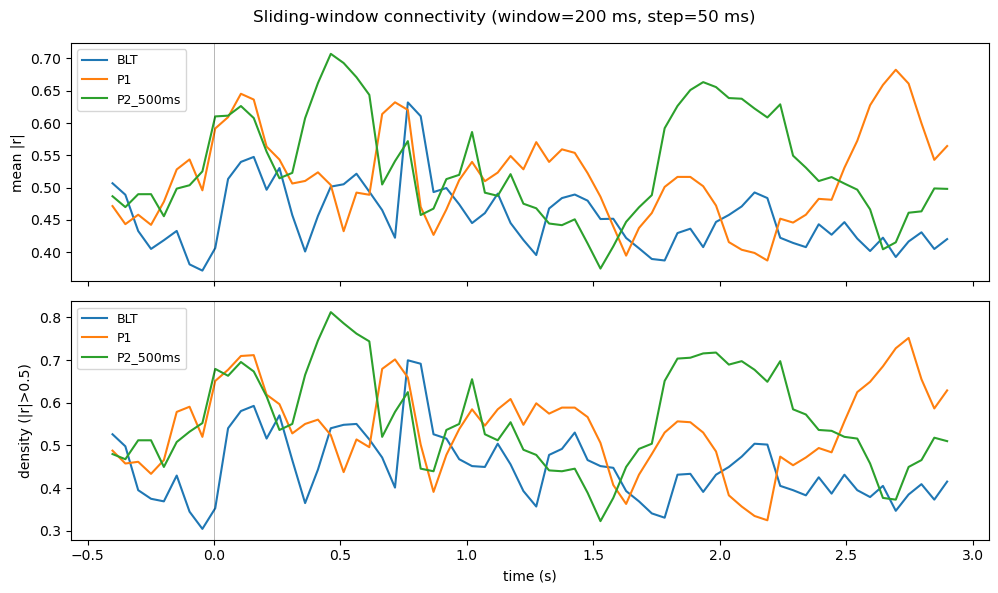

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for name, res in results.items():
    m = summary_metrics(res['corr'])
    axes[0].plot(res['centers'], m['mean_abs_r'], label=name)
    axes[1].plot(res['centers'], m['density'], label=name)
axes[0].set_ylabel('mean |r|')
axes[1].set_ylabel('density (|r|>0.5)')
axes[1].set_xlabel('time (s)')
for ax in axes:
    ax.axvline(0, color='k', lw=0.5, alpha=0.4)
    ax.legend(loc='best', fontsize=9)
fig.suptitle(f'Sliding-window connectivity (window={WINDOW_MS} ms, step={STEP_MS} ms)')
plt.tight_layout()
plt.show()

## E. Heatmap grid at key time points

Pick a few window indices and show the full `n_ch x n_ch` matrix for each condition.

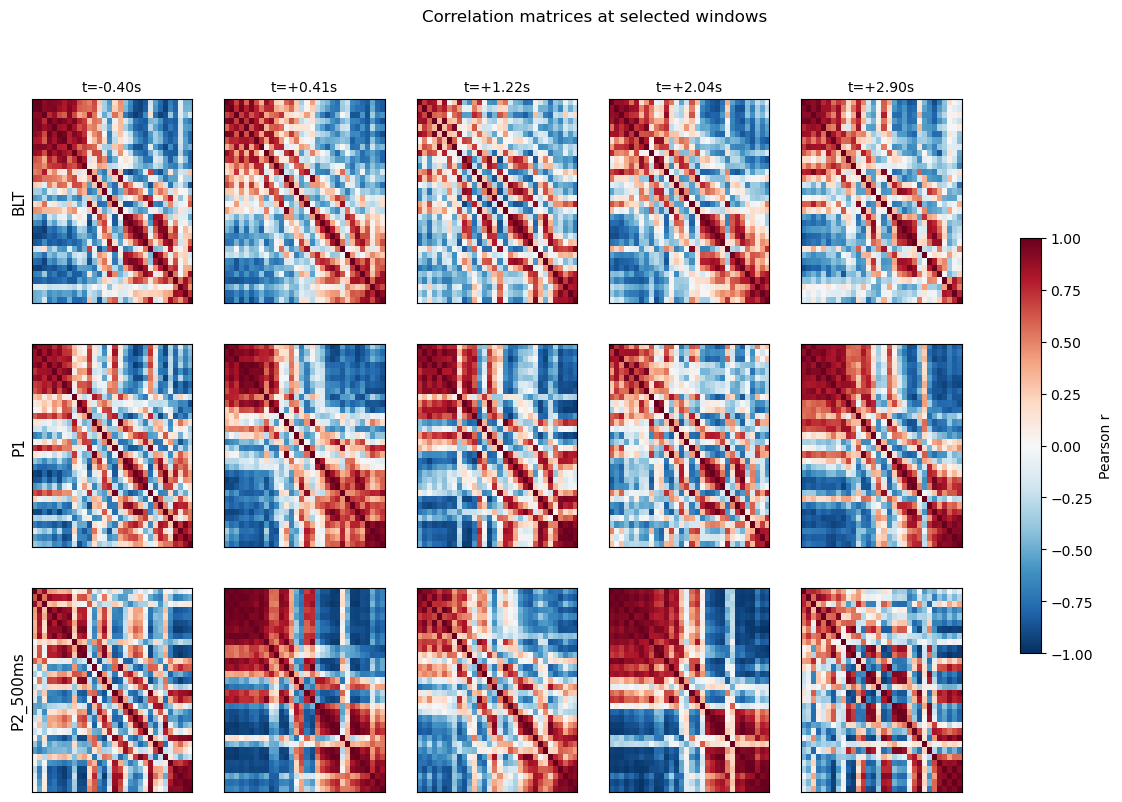

In [10]:
centers = results['BLT']['centers']
n_windows = len(centers)
# Pick 5 evenly spaced windows across the epoch.
pick_idx = np.linspace(0, n_windows - 1, 5, dtype=int)
pick_times = centers[pick_idx]

cond_names = list(results.keys())
fig, axes = plt.subplots(
    len(cond_names), len(pick_idx),
    figsize=(3.0 * len(pick_idx), 3.0 * len(cond_names)),
    squeeze=False,
)
for i, name in enumerate(cond_names):
    corr = results[name]['corr']
    for j, w in enumerate(pick_idx):
        ax = axes[i, j]
        im = ax.imshow(corr[w], vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f't={pick_times[j]:+.2f}s', fontsize=10)
        if j == 0:
            ax.set_ylabel(name, fontsize=11)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='Pearson r')
fig.suptitle('Correlation matrices at selected windows')
plt.show()

## F. Condition-difference heatmaps

P1 - BLT isolates the effect of adding the auditory cue (with a fixed 500 ms gap). P2_500ms - P1 isolates paradigm/block differences when the audio->tactile interval is matched.

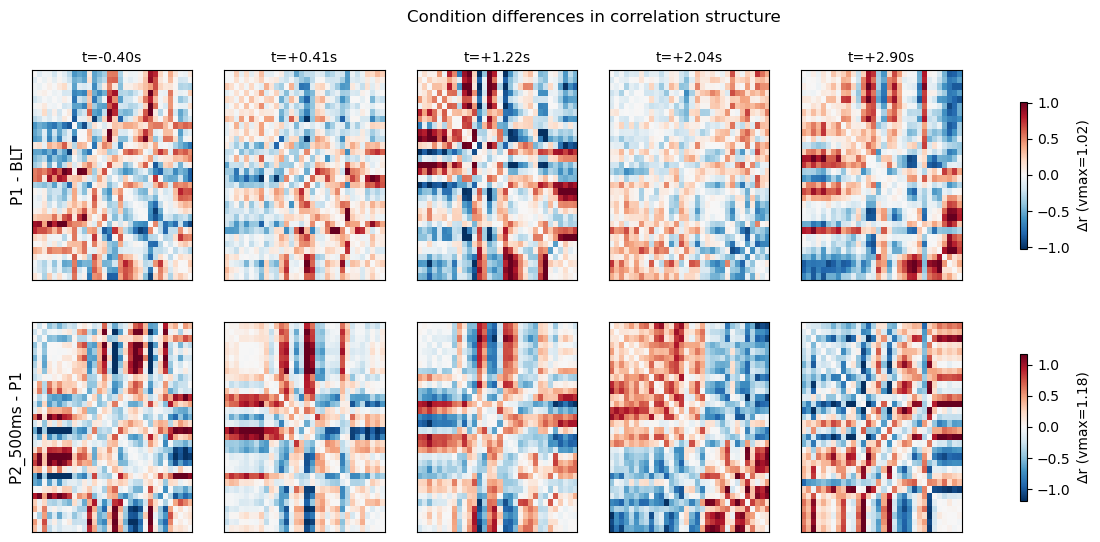

In [11]:
diffs = {
    'P1 - BLT': results['P1']['corr'] - results['BLT']['corr'],
    'P2_500ms - P1': results['P2_500ms']['corr'] - results['P1']['corr'],
}
# Symmetric color range per diff for fair reading.
fig, axes = plt.subplots(
    len(diffs), len(pick_idx),
    figsize=(3.0 * len(pick_idx), 3.0 * len(diffs)),
    squeeze=False,
)
for i, (name, d) in enumerate(diffs.items()):
    vmax = np.nanpercentile(np.abs(d), 99)
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0
    for j, w in enumerate(pick_idx):
        ax = axes[i, j]
        im = ax.imshow(d[w], vmin=-vmax, vmax=vmax, cmap='RdBu_r', aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f't={pick_times[j]:+.2f}s', fontsize=10)
        if j == 0:
            ax.set_ylabel(name, fontsize=11)
    fig.colorbar(im, ax=axes[i, :].tolist(), shrink=0.7, label=f'\u0394r (vmax={vmax:.2f})')
fig.suptitle('Condition differences in correlation structure')
plt.show()

## linear lag testing

In [12]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [15]:
LAGS_SEC   = np.linspace(-0.04, 0.04, 81)
ROLL       = 10
CONDS      = {'P1': p1}     # {'BLT': blt, 'P1': p1, 'P2_500ms': p2}

results = {
    name: dict(zip(
        ['corr', 'raw_corr', 'centers', 'ch_names'],
        sliding_lagged_diff_corr_from_epochs(ep, WINDOW_MS, STEP_MS, LAGS_SEC)
    ))
    for name, ep in CONDS.items()
}

for name, r in results.items():
    print(f"{name}: corr {r['corr'].shape}  centers [{r['centers'][0]:.3f}s .. {r['centers'][-1]:.3f}s]")

# Unpack P1 for convenience
p1_res    = results['P1']
diff_corr = p1_res['corr']       # (n_windows, n_lags, n_ch, n_ch) — differences
raw_corr  = p1_res['raw_corr']   # (n_windows, n_lags, n_ch, n_ch) — actual values
ch_names  = p1_res['ch_names']
centers   = p1_res['centers']

# Global optimal lag: lag whose mean temporal variance is lowest across all pairs
temporal_variance      = raw_corr.var(axis=0)            # (n_lags, n_ch, n_ch)
global_variance        = temporal_variance.mean(axis=(1, 2))  # (n_lags,)
best_lag_global_idx    = global_variance.argmin()
best_lag_global_sec    = LAGS_SEC[best_lag_global_idx]

# Color limits for diff_corr plots
clim = np.nanpercentile(np.abs(diff_corr), 99)

P1: corr (66, 81, 32, 32)  centers [-0.400s .. 2.900s]


In [ ]:
def compute_local_stats(time_idx: int) -> dict:
    """
    For a rolling window around `time_idx`, return per-pair lag stats:
      - best_lag_idx  : (n_ch, n_ch) index into LAGS_SEC
      - best_lag_sec  : (n_ch, n_ch) seconds
      - mean_corr     : correlation at that lag, averaged over the window
      - variance      : variance at that lag
      - graph_weights : thresholded by median variance (bottom 50% kept)
    """
    t0, t1      = max(0, time_idx - ROLL), min(raw_corr.shape[0], time_idx + ROLL + 1)
    local_raw   = raw_corr[t0:t1]                         # (window, n_lags, n_ch, n_ch)
    local_var   = local_raw.var(axis=0)                   # (n_lags, n_ch, n_ch)

    # if we wanna look at the strongest mean correlation per pair instead of variance
    # local_mean = local_raw.mean(axis=0)
    # best_idx = local_mean.argmin(axis=0)

    best_idx    = local_var.argmin(axis=0)                # (n_ch, n_ch)
    best_sec    = LAGS_SEC[best_idx]
    mean_corr   = np.take_along_axis(
        local_raw.mean(axis=0), best_idx[np.newaxis], axis=0
    ).squeeze(0)
    best_var    = np.take_along_axis(
        local_var, best_idx[np.newaxis], axis=0
    ).squeeze(0)

    threshold     = np.percentile(best_var, 50)
    graph_weights = np.where(best_var < threshold, mean_corr, 0)

    return dict(
        best_lag_idx=best_idx,
        best_lag_sec=best_sec,
        mean_corr=mean_corr,
        variance=best_var,
        graph_weights=graph_weights,
    )

def _label_matrix_ax(ax, ch_names):
    ax.set_xticks(range(len(ch_names)))
    ax.set_yticks(range(len(ch_names)))
    ax.set_xticklabels(ch_names, rotation=90, fontsize=6)
    ax.set_yticklabels(ch_names, fontsize=6)

def plot_dashboard(time_idx: int, lag_idx: int):
    lag  = LAGS_SEC[lag_idx]
    tcen = centers[time_idx]
    loc  = compute_local_stats(time_idx)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)

    # [0,0] Manual lag slider — diff corr at chosen lag
    im = axes[0, 0].imshow(diff_corr[time_idx, lag_idx],
                            vmin=-clim, vmax=clim, cmap='RdBu_r', aspect='equal')
    axes[0, 0].set_title(f'Δ Corr  |  lag={lag:+.3f}s')
    fig.colorbar(im, ax=axes[0, 0], label='Δ Pearson r', shrink=0.8)

    # [0,1] Global stability curve
    axes[0, 1].plot(LAGS_SEC * 1000, global_variance, color='steelblue')
    axes[0, 1].axvline(best_lag_global_sec * 1000, color='r', linestyle='--',
                       label=f'optimal = {best_lag_global_sec * 1000:+.1f}ms')
    axes[0, 1].set(xlabel='Lag (ms)', ylabel='Mean temporal variance',
                   title='Stability across lags (global)')
    axes[0, 1].legend(fontsize=9)

    # [0,2] Raw corr at global optimal lag
    corr_global = raw_corr[time_idx, best_lag_global_idx]
    vmax_g      = np.abs(raw_corr[:, best_lag_global_idx]).max()
    im = axes[0, 2].imshow(corr_global, cmap='RdBu_r', aspect='equal',
                            vmin=-vmax_g, vmax=vmax_g)
    axes[0, 2].set_title(f'Corr at global optimal lag ({best_lag_global_sec * 1000:+.1f}ms)')
    fig.colorbar(im, ax=axes[0, 2], label='Pearson r', shrink=0.8)

    # [1,0] Per-pair optimal lag map
    im = axes[1, 0].imshow(loc['best_lag_sec'], cmap='RdBu_r', aspect='equal',
                            vmin=-LAGS_SEC.max(), vmax=LAGS_SEC.max())
    axes[1, 0].set_title('Per-pair optimal lag (s)')
    fig.colorbar(im, ax=axes[1, 0], label='lag (s)', shrink=0.8)

    # [1,1] Corr at per-pair optimal lag
    vmax_pp = np.abs(loc['mean_corr']).max()
    im = axes[1, 1].imshow(loc['mean_corr'], cmap='RdBu_r', aspect='equal',
                            vmin=-vmax_pp, vmax=vmax_pp)
    axes[1, 1].set_title('Corr at per-pair optimal lag')
    fig.colorbar(im, ax=axes[1, 1], label='Pearson r', shrink=0.8)

    # [1,2] Thresholded graph weights
    vmax_w = np.abs(loc['graph_weights']).max() or 1
    im = axes[1, 2].imshow(loc['graph_weights'], cmap='RdBu_r', aspect='equal',
                            vmin=-vmax_w, vmax=vmax_w)
    axes[1, 2].set_title('Graph weights (thresholded)')
    fig.colorbar(im, ax=axes[1, 2], label='Pearson r', shrink=0.8)

    matrix_axes = [axes[0, 0], axes[0, 2], axes[1, 0], axes[1, 1], axes[1, 2]]
    for ax in matrix_axes:
        _label_matrix_ax(ax, ch_names)

    fig.suptitle(
        f't = {tcen:+.3f}s  |  lag = {lag:+.3f}s  |  local window = ±{ROLL} steps',
        fontsize=12,
    )
    plt.show()

In [ ]:
%matplotlib inline

time_slider = widgets.SelectionSlider(
    options=[(f'{t:+.3f}s', i) for i, t in enumerate(centers)],
    description='Time:',
    layout=widgets.Layout(width='700px'),
)
lag_slider = widgets.SelectionSlider(
    options=[(f'{l:+.3f}s', i) for i, l in enumerate(LAGS_SEC)],
    description='Lag:',
    layout=widgets.Layout(width='700px'),
)
out = widgets.Output()

def redraw(_=None):
    with out:
        clear_output(wait=True)
        plot_dashboard(time_slider.value, lag_slider.value)

time_slider.observe(redraw, names='value')
lag_slider.observe(redraw, names='value')
display(widgets.VBox([time_slider, lag_slider, out]))
redraw()